In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

In [85]:
siga = 1
sigb = 2
sigab = 1.5
N=10000

comab = np.random.normal(0, sigab, N)
a = np.random.normal(0, siga, N)+comab
b = np.random.normal(0, sigb, N)-comab
c = -a-b

row = np.arange(0, N)

ds = xr.Dataset(
    data_vars=dict(
        a=("row", a),
        b=("row", b),
        c=("row", c),
    ), 
    coords=dict(row=("row", row)
               )
)
ds['s'] = ds.a + ds.b + ds.c
ds['exca'] = ds.b + ds.c
ds['excb'] = ds.a + ds.c
ds['excc'] = ds.a + ds.b

ds['Xab'] = -2*ds.a*ds.b
ds['Xbc'] = -2*ds.b*ds.c
ds['Xac'] = -2*ds.a*ds.c

ds['Ea'] = a*ds.s
ds['Eb'] = b*ds.s
ds['Ec'] = c*ds.s

ds['Ba'] = -a*ds.exca
ds['Bb'] = -b*ds.excb
ds['Bc'] = -c*ds.excc

v2 = ['a', 'b', 'c', 's', 'exca', 'excb', 'excc']

dm2 = (ds[v2]**2)
dm = ds[[v for v in ds if v not in v2]]

dm = xr.merge([dm, dm2]).mean('row')

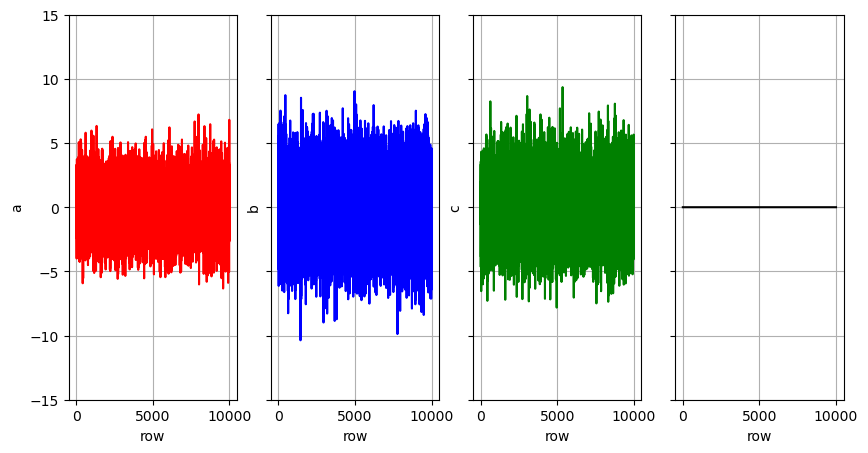

In [86]:
fig, axs =plt.subplots(1,4, sharey=True, figsize = (10, 5))
ds.a.plot(c='r', ax=axs[0])
ds.b.plot(c='b', ax=axs[1])
ds.c.plot(c='g', ax=axs[2])
(ds.a+ds.b+ds.c).plot(c='k', ax=axs[3])

for ax in axs:
    ax.grid()
    ax.set_ylim(-15, 15)

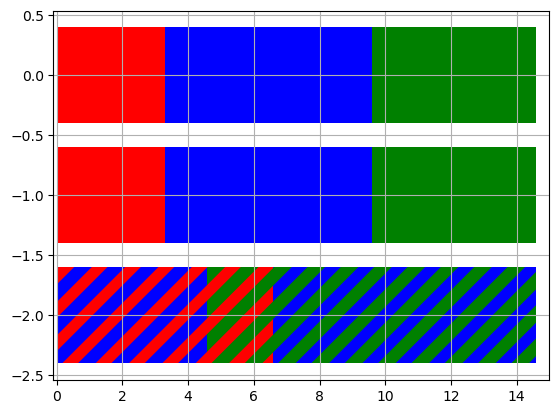

In [87]:
fig, ax = plt.subplots(1,1)

ax.barh(0, dm.a, color='r')
ax.barh(0, dm.b, left=dm.a, color='b')
ax.barh(0, dm.c, left=dm.b+dm.a, color='g')

ax.barh(-1, dm.Ba, color='r')
ax.barh(-1, dm.Ea, left=dm.Ba, color='grey')
ax.barh(-1, dm.Bb, left=dm.Ba +dm.Ea, color='b')
ax.barh(-1, dm.Eb, left=dm.Ba +dm.Ea+dm.Bb, color='grey')
ax.barh(-1, dm.Bc, left=dm.Ba +dm.Ea+dm.Bb+dm.Eb, color='g')
ax.barh(-1, dm.Ec, left=dm.Ba +dm.Ea+dm.Bb+dm.Eb+dm.Bc, color='grey')

plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'r'
ax.barh(-2, dm.Xab, color='b', hatch = '/')
ax.barh(-2, dm.Xac,left = dm.Xab, color='g', hatch = '/')
plt.rcParams["hatch.color"] = 'b'
ax.barh(-2, dm.Xbc,left =dm.Xab+dm.Xac,  color='g', hatch = '/')

ax.set_xlim(-0.1, 15)
ax.grid()

In [88]:
dsa  = ds[['b', 'c']]
dsa['s'] =  dsa.b + dsa.c
dsa['excb'] = dsa.c
dsa['excc'] = dsa.b

dsa['Xbc'] = -2*dsa.b*dsa.c

dsa['Eb'] = b*dsa.s
dsa['Ec'] = c*dsa.s

dsa['Bb'] = -b*dsa.excb
dsa['Bc'] = -c*dsa.excc

v2 = [ 'b', 'c', 's', 'excb', 'excc']

dm2a = (dsa[v2]**2)
dma = dsa[[v for v in dsa if v not in v2]]

dma = xr.merge([dma, dm2a]).mean('row')

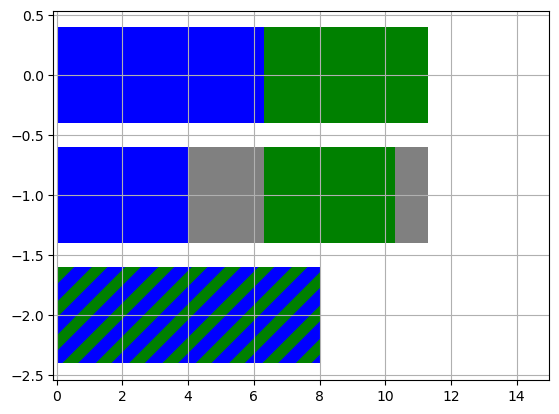

In [89]:
fig, ax = plt.subplots(1,1)

ax.barh(0, dma.b, color='b')
ax.barh(0, dma.c, left=dma.b, color='g')

ax.barh(-1, dma.Bb, color='b')
ax.barh(-1, dma.Eb, left=dma.Bb, color='grey')
ax.barh(-1, dma.Bc, left=dma.Bb+dma.Eb, color='g')
ax.barh(-1, dma.Ec, left=dma.Bb+dma.Eb+dma.Bc, color='grey')

plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'g'
ax.barh(-2, dma.Xbc, color='b', hatch = '/')
ax.set_xlim(-0.1, 15)
ax.grid()

In [90]:
dsc  = ds[['a', 'b']]
dsc['s'] =  dsc.a + dsc.b
dsc['exca'] = dsc.b
dsc['excb'] = dsc.a

dsc['Xab'] = -2*dsc.a*dsc.b

dsc['Ea'] = a*dsc.s
dsc['Eb'] = b*dsc.s

dsc['Ba'] = -a*dsc.exca
dsc['Bb'] = -b*dsc.excb

v2 = [ 'a', 'b', 's', 'exca', 'excb']

dm2c = (dsc[v2]**2)
dmc = dsc[[v for v in dsc if v not in v2]]

dmc = xr.merge([dmc, dm2c]).mean('row')

In [91]:
dmc

<xarray.Dataset> Size: 80B
Dimensions:  ()
Data variables:
    Xab      float64 8B 4.58
    Ea       float64 8B 1.005
    Eb       float64 8B 4.004
    Ba       float64 8B 2.29
    Bb       float64 8B 2.29
    a        float64 8B 3.295
    b        float64 8B 6.294
    s        float64 8B 5.009
    exca     float64 8B 6.294
    excb     float64 8B 3.295

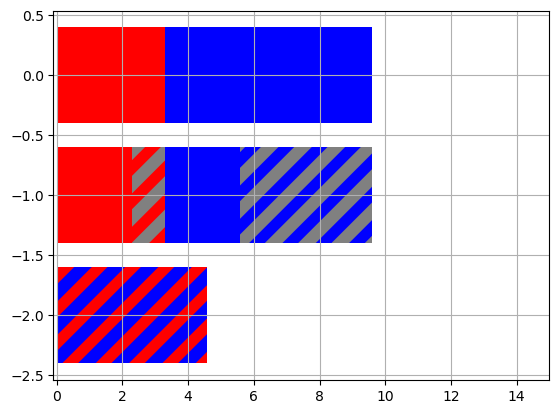

In [92]:
fig, ax = plt.subplots(1,1)

ax.barh(0, dmc.a, color='r')
ax.barh(0, dmc.b, left=dmc.a, color='b')

ax.barh(-1, dmc.Ba, color='r')
plt.rcParams["hatch.color"] = 'r'
ax.barh(-1, dmc.Ea,left = max(dmc.Ba, 0), color='grey', hatch = '/')
ax.barh(-1, dmc.Bb, left=max(dmc.Ba, 0)+max(dmc.Ea, 0), color='b')
plt.rcParams["hatch.color"] = 'b'
ax.barh(-1, dmc.Eb, left=max(dmc.Ba, 0)+max(dmc.Ea, 0)+max(dmc.Bb, 0), color='grey', hatch = '/')


plt.rcParams["hatch.linewidth"] = 8
plt.rcParams["hatch.color"] = 'r'
ax.barh(-2, dmc.Xab, color='b', hatch = '/')
ax.set_xlim(-0.1, 15)
ax.grid()